In [317]:
print("INTRODUCTION", '\n')

print("The data set in use represents the selected U.S. quarterly GDP growth rates from 2010 to 2023.", '\n'
      "The source of this data set is the U.S. Bureau of Economic Analysis(BEA).","\n"
      "The methods I will be implementing for data analysis are:", '\n', "\n"
      "1)The Least Squares Linear Regression", "\n"
      "2)Polynomial Fitting (via natural equations)", "\n"
      "3)Cubic Spline Interpolation (natural)")

INTRODUCTION 

The data set in use represents the selected U.S. quarterly GDP growth rates from 2010 to 2023. 
The source of this data set is the U.S. Bureau of Economic Analysis(BEA). 
The methods I will be implementing for data analysis are: 
 
1)The Least Squares Linear Regression 
2)Polynomial Fitting (via natural equations) 
3)Cubic Spline Interpolation (natural)


In [225]:
#PART A, tasks
print("Part A, these are the tasks to solve:", "\n","\n",  "1.Construct a natural cubic spline interpolant through the full dataset (all provided quarters)", "\n", "2.Clearly describe the system of equations you solve: how many unknowns are there", "\n", "3.What are the continuity conditions at each interior knot, and what boundary conditions define a natural spline?", "\n",
      "4. Using your spline from the subset above, evaluate it at every quarter in the full range and plot the result. Discuss", "\n", " whether the interpolant is visually smooth and reasonable.", "\n", "5.Discuss the Runge's phenomenon and the trade-off between exact interpolation and numerical stability for datasets with extreme outliers. Would smoothing splines or weighted least squares be preferable here?", "\n")

Part A, these are the tasks to solve: 
 
 1.Construct a natural cubic spline interpolant through the full dataset (all provided quarters) 
 2.Clearly describe the system of equations you solve: how many unknowns are there 
 3.What are the continuity conditions at each interior knot, and what boundary conditions define a natural spline? 
 4. Using your spline from the subset above, evaluate it at every quarter in the full range and plot the result. Discuss 
  whether the interpolant is visually smooth and reasonable. 
 5.Discuss the Runge's phenomenon and the trade-off between exact interpolation and numerical stability for datasets with extreme outliers. Would smoothing splines or weighted least squares be preferable here? 



DISCLAIMER: In this code, x represents the quarter values per each year on the data set, and y represents the GDP growth, in percent,for each of the aforementioned quarters. 

This is the elapsed time to run this method(in seconds):  
 0.004360459744930267


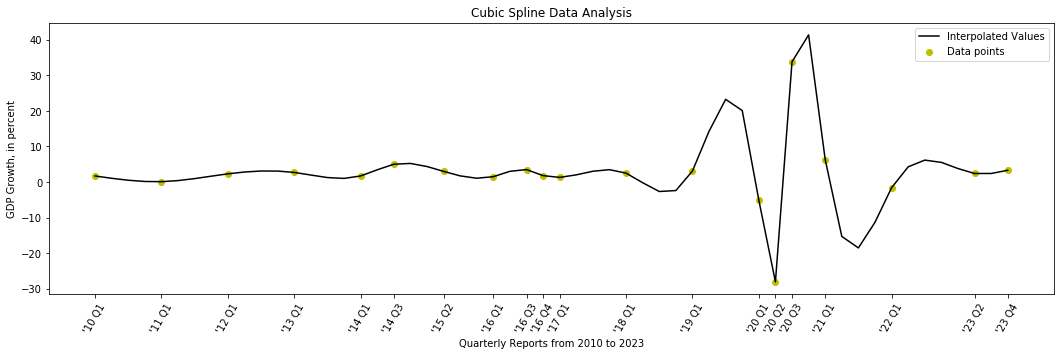

DISCUSSION OF RESULTS 

1) The boundary conditions that satisfy a natural cubic spline are that the second derivatives at the endpoints of 
 the global system must be equal to 0- thus the name of natural cubic spline. 
 As for the unknowns, we have the vector of second derivatives, M, that we solve using the tridiagonal matrix function 
 at each of the interior knots. 

2) From the resulting plot, we notice that the interpolant is visually smooth and reasonable prior to the interval between 
  2019 and 2021, where the data tends to show large fluctuations. After this interval, the plot seems to stabilize 
 and becomes smooth again. 

3) The Runge phenomenon is where high polynomial interpolation exhibits wild oscillations near the edges of the interval 
 that the given function spans. 
 
 4)The tradeoff between exact interpolation and numerical stability for datasets with extreme outliers is that exact interpolation forces the model to pass through every data point, even noisy or erron

In [4]:
#Part A, implementation
import numpy as np
import matplotlib.pyplot as plt
import time
print("DISCLAIMER: In this code, x represents the quarter values per each year on the data set, and y represents the GDP growth, in percent,"
      "for each of the aforementioned quarters.", "\n")

x = [10.0, 11.0, 12.0, 13.0, 14.0, 14.5, 15.25, 16.0, 16.5, 16.75, 17.0, 18.0, 19.0, 20.0, 20.25, 20.5, 21.0, 22.0, 23.25, 23.75 ]

y = [1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]

labels = ["'10 Q1", "'11 Q1", "'12 Q1", "'13 Q1", "'14 Q1", "'14 Q3", "'15 Q2", "'16 Q1", "'16 Q3", "'16 Q4", "'17 Q1", "'18 Q1", "'19 Q1", "'20 Q1", "'20 Q2", "'20 Q3", "'21 Q1", "'22 Q1", "'23 Q2", "'23 Q4"]

#Creation of Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    a = np.array(a, dtype= float)
    b = np.array(b, dtype= float)
    c = np.array(c, dtype= float)
    d = np.array(d, dtype= float)

    for i in range(1,n):
        w = a[i] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i]- c[i]* x[i+1])/ b[i]
    return x

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
# Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
# Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i -1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ( (y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1] ) # Right-hand side vector

    M_second = thomas_algorithm(A, B, C, D)
    # Natural boundary conditions
    M = np.zeros(n)
    M[1:n - 1] = M_second
    return M

#Finding the correct interval for each point, I got this part from slides in 13.b

#This part evaluates C0, C1, and C2 continuity through the construction of the tridiagonal matrix- form this, the spline ensures continuity through each knot where first and second derivatives are continuous between each interval. 
def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    
    h = np.diff(x_data)
    i = np.searchsorted(x_data, x_query, side='right') - 1
    
    i = np.clip(i, 0, n - 2)
    
    
    hi = h[i]
    dx_left = x_query - x_data[i] 
    
    
    dx_right = x_data[i+1] - x_query
    S = (
        (M[i] / (6*hi)) * dx_right**3 + 
        (M[i+1] / (6*hi)) * dx_left**3 + 
        (y_data[i] /hi - M[i] *hi/6) * dx_right + 
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left)
    return S

#Run time
start_time = time.perf_counter()
M = setup_tridiagonal_matrix(x, y)
x_s = np.linspace(x[0], x[-1], 56)

#In this part I included the first and last points in an evenly spaced number of data points

S_interpolated =  [evaluate_spline(x, y, M, l) for l in x_s] 

end_time = time.perf_counter()
elapsed_time1 = end_time - start_time
print("This is the elapsed time to run this method(in seconds): ", '\n', elapsed_time1)

#Plotting the results
plt.figure(figsize=(18, 5))
plt.scatter(x, y, marker= 'o', color = 'y', label='Data points')
plt.plot(x_s, S_interpolated, color='k', label= 'Interpolated Values')
plt.title("Cubic Spline Data Analysis")
plt.xlabel("Quarterly Reports from 2010 to 2023")
plt.ylabel("GDP Growth, in percent")
plt.xticks(x, labels, rotation=60)
plt.legend()
plt.show()

#DISCUSSION
print("DISCUSSION OF RESULTS", "\n")

print("1) The boundary conditions that satisfy a natural cubic spline are that the second derivatives at the endpoints of", "\n", "the global system must be equal to 0- thus the name of natural cubic spline."
      ,'\n', "As for the unknowns, we have the vector of second derivatives, M, that we solve using the tridiagonal matrix function", "\n", "at each of the interior knots.", "\n")

print("2) From the resulting plot, we notice that the interpolant is visually smooth and reasonable prior to the interval between", "\n"," 2019 and 2021, where the data tends to show large fluctuations. After this interval, the plot seems to stabilize", '\n', "and becomes smooth again.", '\n')

print("3) The Runge phenomenon is where high polynomial interpolation exhibits wild oscillations near the edges of the interval", "\n","that the given function spans.", "\n", '\n',"4)The tradeoff between exact interpolation and numerical stability for datasets with extreme outliers is that exact interpolation forces the model to pass through every data point, even noisy or erroneous points, which can lead to high variance", "\n", "and overfitting. In this concrete example, the Cubic spline method is highly accurate before the COVID data points-", "\n", "where such dramatic values causes trends in the graph that probably never existed."
     '\n')

print("5)For this specific case, smoothing the data further would continue to have wild oscillations near the end due to the nature of Cubic splines to hit every single data point. I would utilize a weighted least squares because this model would give less weight, or less presence in the model, to data with high variance- therefore, constructing a more precise graph.")

print('\n'"6)One last thing, since both the Thomas Algorithm and the Tridiagonal matrix functions only pass through the data once, we would have a Big O notation of O(n). This would be a very efficient method to solve than solving a full linear system and woul'nt be as computationally expensive. Note that, according to freecodecamp.org, Big O notation describes the complexity of your code using algebraic terms- in other words,a tool that measures how much work does the algorithm has to do.")

print('\n' "This is the source: https://www.freecodecamp.org/news/big-o-notation-why-it-matters-and-why-it-doesnt-1674cfa8a23c/")

In [295]:
#PART B, tasks
print("Part B, I,  these are the tasks to solve:", '\n','\n', "1)Fit a degree-4 polynomial to the data using least squares (this does not need to pass through every point).", '\n', "2) Plot it alongside the cubic spline. Which model better captures the overall trend, and which better reproduces specific ", "\n", "data points?","\n", "3) Discuss the trade-off between approximation and interpolation.")

print("\n", "Part B, II, these are the tasks to solve:", '\n', '\n', "1)Fit a least squares linear model to the data excluding the COVID quarters (2020 Q1–2021 Q1).", '\n', "2)Report the slope. Does a linear trend make economic sense for this data?", '\n', "3)What assumptions does it require?")

Part B, I,  these are the tasks to solve: 
 
 1)Fit a degree-4 polynomial to the data using least squares (this does not need to pass through every point). 
 2) Plot it alongside the cubic spline. Which model better captures the overall trend, and which better reproduces specific  
 data points? 
 3) Discuss the trade-off between approximation and interpolation.

 Part B, II, these are the tasks to solve: 
 
 1)Fit a least squares linear model to the data excluding the COVID quarters (2020 Q1–2021 Q1). 
 2)Report the slope. Does a linear trend make economic sense for this data? 
 3)What assumptions does it require?


I) 

This is the elapsed time to run this method(in seconds):  
 0.001665007323026657 

Your conditioning is acceptable, proceeding... 

Computing MSE and R squared for Vandermonde: 

Mean Squared Error for Vandermonde---------- 99.3077379621237
R squared for Vandermonde------------------ 0.016632392138784757
RMSE for Vandermonde--------------- 9.965326786519531


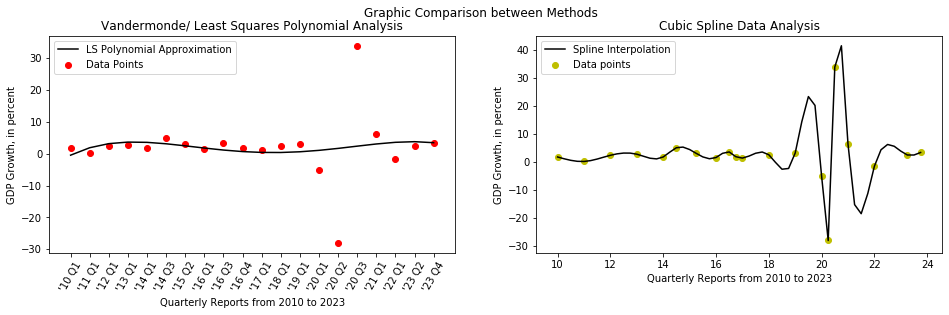

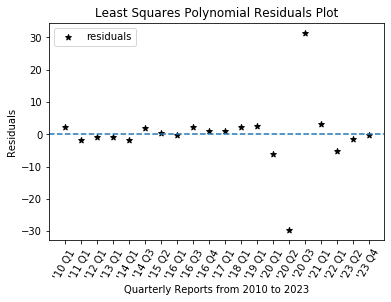

DISCUSSION OF RESULTS 
 

From the visual results obtained after applying both methods, we might think that the Cubic spline appears to be accurately describing the overall trend by smoothly including every single data point. However, we notice that there is an extreme outlier coming from 2020 Q1 through 2021 Q1, which are the dramatic values from COVID. Because of that, in this particular scenario, the L.S Polynomial is less sensitive to high fluctuations in data and is providing a stable model without severe oscillations like the Cubic spline- making it a more accurate depiction of the actual trends. 

In addition, we can analyze the metrics given by the MSE and R-squared values. Here, when we calculate them, we get that the L.S Polynomial would have a MSE value of 99.3 and R-squared of 0.016 (For context, a value of R-squared close to 1 means and a value of MSE close to 0 means it is a great approximation). Such values could indicate that the approximated line is not a good fit for 

In [3]:
#PART B, implementation, I
import math
print("I)", "\n")

#Building the Vandermonde
x = [10.0, 11.0, 12.0, 13.0, 14.0, 14.5, 15.25, 16.0, 16.5, 16.75, 17.0, 18.0, 19.0, 20.0, 20.25, 20.5, 21.0, 22.0, 23.25, 23.75 ]
#I modified the x values to be consecutive integers because utilizing raw calendar decimals as previously done would create a numerically unstable system with widly scaled matrices 
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
x_2 = np.arange(1, len(y)+1)

degree = 4

#Run time
start_time = time.perf_counter()

V = np.vander(x_2, N= degree +1, increasing = True)

Vs = np.dot(V.T, V)

Vp = np.dot(V.T, y)

#Finding the coefficients on the Vandermonde matrix
coefficients  = np.linalg.solve(Vs, Vp)

y_pred = V @ coefficients

end_time = time.perf_counter()
elapsed_time1 = end_time - start_time
print("This is the elapsed time to run this method(in seconds): ", '\n', elapsed_time1, '\n')

#Checking conditioning

con = np.linalg.cond(V)

if (con > 1e12):
    print("Your V value is il-conditioned, please reconsider your basis or degree")
else:
    print("Your conditioning is acceptable, proceeding...", '\n')

#Calculating metrics
print("Computing MSE and R squared for Vandermonde:", "\n")
mse_poly = np.mean((y - (y_pred))**2)
print("Mean Squared Error for Vandermonde----------", mse_poly)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_pred))**2)
r_squared_poly = 1 - (ss_res / ss_total)
print("R squared for Vandermonde------------------", r_squared_poly)
rmse = np.sqrt(mse_poly)
print("RMSE for Vandermonde---------------", rmse)

#I got this portion of subplots from https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Graphic Comparison between Methods')

#Vandermonde Graph
ax1.plot(x_2,y_pred, color="k", label = 'LS Polynomial Approximation')
ax1.scatter(x_2,y, marker = "o", color= 'r', label='Data Points')
ax1.set_xticks(x_2)
ax1.set_xticklabels(labels, rotation=60)
ax1.set_xlabel("Quarterly Reports from 2010 to 2023")
ax1.set_ylabel("GDP Growth, in percent")
ax1.set_title("Vandermonde/ Least Squares Polynomial Analysis")
ax1.legend()
#Cubic Spline Graph
ax2.plot(x_s, S_interpolated, color = 'k', label= 'Spline Interpolation')
ax2.scatter(x, y, marker= 'o', color = 'y', label='Data points')
ax2.set_title("Cubic Spline Data Analysis")
ax2.set_xlabel("Quarterly Reports from 2010 to 2023")
ax2.set_ylabel("GDP Growth, in percent")
ax2.legend()
plt.show()

#Plotting Residuals 

residuals = y - y_pred
plt.scatter(len(x_2), residuals, marker = '*', color = 'k', label= "residuals")
plt.xticks(x_2, labels, rotation=60)
plt.xlabel("Quarterly Reports from 2010 to 2023")
plt.ylabel("Residuals")
plt.title("Least Squares Polynomial Residuals Plot")
#Got this part from https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axhline.html
plt.axhline(0, linestyle='--') 
plt.legend()
plt.show()

print("DISCUSSION OF RESULTS", "\n", "\n")

print("From the visual results obtained after applying both methods, we might think that the Cubic spline appears to be accurately describing", "the overall trend by smoothly including every single data point. However, we notice that there is an extreme outlier coming from 2020 Q1 through 2021 Q1, which are the dramatic values from COVID. Because of that, in this particular scenario, the L.S Polynomial is less sensitive to high fluctuations in data and is providing a stable model without severe oscillations like the Cubic spline- making it a more accurate depiction of the actual trends. ")

print("\n" "In addition, we can analyze the metrics given by the MSE and R-squared values. Here, when we calculate them, we get that the L.S Polynomial would have a MSE value of 99.3 and R-squared of 0.016 (For context, a value of R-squared close to 1 means and a value of MSE close to 0 means it is a great approximation). Such values could indicate that the approximated line is not a good fit for this model, and given that the MSE and R-squared are not a good metric to use for Cubic splines, we can only say that, at least visually, the Cubic spline has a better approximation. The RMSE value indicates the magnitude of prediction errors, where a value of almost 10 tells us that the polynomial approximation deviates from the GDP values, in percent, in our data set")

print("\n" "The tradeoff here between approximation and interpolation would be for that the least squares polynomial approximation reduces the large fluctuations that extreme outliers represent, but the low R-squared value is indicating that the Polynomial is not capturing the variability of the data as it should be. In the other hand, a Cubic spline would interpolate every single point and create a smooth line but is susceptible to large oscillations due to outliers, which would be the tradeoff between approximation and interpolation in this case.")

print("\n" "As previously mentioned, the data set in use contains significant outliers for the COVID period, which causes great distortions for both Cubic spline and LS Polynomial methods. If we concentrate on the residuals plot, it is revealed that the poor fit metrics are driven by those extreme residuals in our data set. But, overall, our graph also reveals that the model maintains relative smaller and consistent residuals elsewhere, which means that we have a really smooth approximation for our LS Polynomial method-capturing the overall trend.")

print('\n' "In this case, the Least Squares Polynomial has a complexity of O(nl^2+l^3), where l is the degree and n is the number of data points. Since the degree is fixed to be 4, we would have both l to be constants, thus making Big O notation to also be O(n)- just like the Cubic Spline, so Big O notation is not a motive to change my recommendation. However, if we compare run times, we notice that the Cubic Spline method took 0.0070 seconds to solve, and the Polynomial took 0.0010 seconds. Because of this, I would still suggest to utilize the Least Squares Polynomial because it took less time to run(less computationally expensive).")

II) 

This is the elapsed time to run this method(in seconds):  
 0.0005218051373958588 

MSE AND R SQUARED 

Mean Squared error for Linear Least Squares method: 2.083710477941176
R squared for Linear Least Squares method: 2.2054826109840775e-07
RMSE for Linear Least Squares Method: 1.4435063137863915

VALUES FOR THE SLOPE AND EQUATION OF THE LINE 

This is the slope for the given model: 0.00014705882352951386 
This is the overall equation: y = 0.00014705882352951386x + 2.1424999999999996


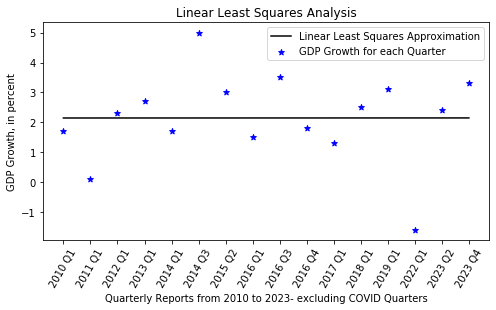

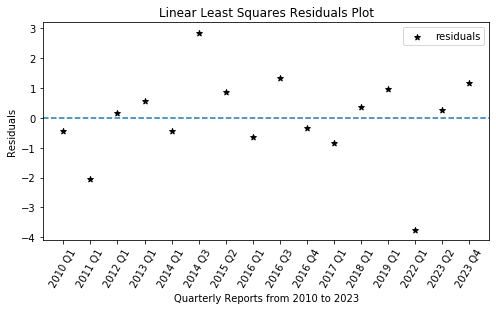

DISCUSSION OF RESULTS: 
 

For representing economic data over time, it is tempting to say that the linear graph excluding COVID years, or the outliers, is a good idea to implement and accurately describe the economic trends over time and produces a reasonable slope of ~0.00014 percent. However, by doing so, we are assuming that there would not be important variances during certain periods of time that provoke high fluctuations in graphs for Least Squares or Cubic splines 
 
Our data here is not liable to be linearly proportional over time, as shown by an innacurate representation of the trend in the residuals plot,  and if periods like this can occur at any given time, we cannot accurately rely on linear as we had to exclude that data in order to make a great linear approximation of our data. In other words, for the given data excluding COVID, a linear model makes economic sense- but makes dangerous assumptions that might not always be true in global economies.


In [9]:
#PART B, implementation, II 

print("II)", "\n")

#Least Squares, excluding COVID quarters

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

x = np.arange(1, len(y)+1)

labels_16 = ["2010 Q1","2011 Q1","2012 Q1","2013 Q1", "2014 Q1","2014 Q3","2015 Q2","2016 Q1","2016 Q3","2016 Q4","2017 Q1","2018 Q1","2019 Q1","2022 Q1","2023 Q2","2023 Q4"]

#Run time
start_time = time.perf_counter()

A = np.vstack([x, np.ones(len(x))]).T

# Solving using linear least squares
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
y_lsr = m * x + c

end_time = time.perf_counter()
elapsed_time1 = end_time - start_time
print("This is the elapsed time to run this method(in seconds): ",'\n', elapsed_time1, '\n')

#Finding the MSE and R squared as well as the slope and the equation of the line
print("MSE AND R SQUARED", '\n')
mse_poly = np.mean((y - (y_lsr))**2)
print("Mean Squared error for Linear Least Squares method:", mse_poly)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - (y_lsr))**2)
r_squared_poly = 1 - (ss_res / ss_total)
rmse = np.sqrt(mse_poly)
print("R squared for Linear Least Squares method:", r_squared_poly)
print("RMSE for Linear Least Squares Method:", rmse)
print('\n' 'VALUES FOR THE SLOPE AND EQUATION OF THE LINE \n')
print(f"This is the slope for the given model: {m}", "\n" f"This is the overall equation: y = {m}x + {c}")

#Plotting
plt.figure(figsize=(8,4))
plt.scatter(x, y, marker = "*", color= 'b', label= "GDP Growth for each Quarter")
plt.plot(x,y_lsr, color = "k", label = "Linear Least Squares Approximation")
plt.title("Linear Least Squares Analysis")
plt.xlabel("Quarterly Reports from 2010 to 2023- excluding COVID Quarters")
plt.ylabel("GDP Growth, in percent")
plt.xticks(x, labels_16, rotation =60)
plt.legend()
plt.show()

#Plotting Residuals 
plt.figure(figsize=(8,4))
residuals = y - y_lsr
plt.scatter(x, residuals, marker = '*', color = 'k', label= "residuals")
plt.xlabel("Quarterly Reports from 2010 to 2023")
plt.ylabel("Residuals")
plt.title("Linear Least Squares Residuals Plot")
plt.xticks(x, labels_16, rotation =60)
#Got this part from https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axhline.html
plt.axhline(0, linestyle='--') 
plt.legend()
plt.show()

#DISCUSSION

print("DISCUSSION OF RESULTS:", "\n", "\n")

print("For representing economic data over time, it is tempting to say that the linear graph excluding COVID years, or the outliers, is a good idea to implement and accurately describe the economic trends over time and produces a reasonable slope of ~0.00014 percent. However, by doing so, we are assuming that there would not be important variances during certain periods of time that provoke high fluctuations in graphs for Least Squares or Cubic splines" 
      ,'\n', '\n' "Our data here is not liable to be linearly proportional over time, as shown by an innacurate representation of the trend in the residuals plot,  and if periods like this can occur at any given time, we cannot accurately rely on linear as we had to exclude that data in order to make a great linear approximation of our data. In other words, for the given data excluding COVID, a linear model makes economic sense- but makes dangerous assumptions that might not always be true in global economies.")

In [364]:
#PART C, tasks

print("Part C, these are the tasks:", '\n', '\n' "For a policymaker who needs to estimate GDP growth for a quarter between two known data points (interpolation), which method would you recommend: cubic spline or polynomial"
      ,"fitting? Justify your answer with reference to smoothness, accuracy, and sensitivity to outliers")

Part C, these are the tasks: 
 
For a policymaker who needs to estimate GDP growth for a quarter between two known data points (interpolation), which method would you recommend: cubic spline or polynomial fitting? Justify your answer with reference to smoothness, accuracy, and sensitivity to outliers


In [415]:
#PART C, implementation 

print("METHOD JUSTIFICATION", '\n')

print("For a polycimaker who need to estimate GDP growth for a quarter between two known data points, from 2012 to 2019 for example, a Cubic spline interpolation would be the best option because our constant data would fit a smooth, predictable, and without large fluctuations that could cause oscillations in our graph. Cubic splines provide a continuous function using first and second derivatives, making the values represented between quarters to be realistic and stable.", '\n')
      
      
print("According to the metrics given, our MSE and R-squared values of 99.3 and 0.016 respectively are inherently far from the 0 and 1 values that make a polynomial a good fit. Regardless of the metrics, because the polynomial is dependent on a global system, a natural Cubic Spline would locally evaluate every point and provide a precise interpolation in a data where the data points are stable.")
      
      
print('\n' "If the polycimaker decided to evaluate the range of COVID quarters, that is from 2020 Q1- 2021 Q1, a Cubic spline would begin to oscillate badly due to extreme outliers in that region. In this case, I would recommend a Least Squares polynomial method because, even if it is a little sensitive to outliers as demonstrated by the residuals plot, Runge's phenomenon, it would preserve an overall trend while maintaining a stable numerical accuracy throughout this region.")

METHOD JUSTIFICATION 

For a polycimaker who need to estimate GDP growth for a quarter between two known data points, from 2012 to 2019 for example, a Cubic spline interpolation would be the best option because our constant data would fit a smooth, predictable, and without large fluctuations that could cause oscillations in our graph. Cubic splines provide a continuous function using first and second derivatives, making the values represented between quarters to be realistic and stable. 

According to the metrics given, our MSE and R-squared values of 99.3 and 0.016 respectively are inherently far from the 0 and 1 values that make a polynomial a good fit. Regardless of the metrics, because the polynomial is dependent on a global system, a natural Cubic Spline would locally evaluate every point and provide a precise interpolation in a data where the data points are stable.

If the polycimaker decided to evaluate the range of COVID quarters, that is from 2020 Q1- 2021 Q1, a Cubic spline 

In [427]:
#FINAL PART, CONCLUSION
print("CONCLUSION", '\n', '\n')
print("In this data analysis project, I implemented both the natural Cubic Spline interpolation and the Least Squares Linear and Polynomial approximation methods as curve fitting techniques to model quarterly GDP growth data.The Cubic spline performed its best when our data was smooth and consistent throughout the years, as shown by an analysis focused on 2012 through 2019 region in the graphed data. But if we applied this method to the overall data, we would notice that the spline begins to form high fluctuations in regions with extreme outliers- COVID years. In contrast, the Least Squares Polynomial approximation method demonstrated to capture a more consistent trend throughout the years at a cost of losing accuracy that the spline provided and being highly susceptible to outliers(Runge's phenomenon) as demonstrated by the poor MSE and R-squared values. In the end, I learned that both methods are conditioned to specific scenarios where one, as a data analyst, should evaluate the tradeoffs between the Cubic spline and Least Squares Polynomial- which are accuracy but sensible to outliers and stability at the cost of precision respectively. Ultimately, I learned that there are more advanced techniques, such as the Weighted Least Squares, that would offer a better tradeoff between stability and accuracy.")



CONCLUSION 
 

In this data analysis project, I implemented both the natural Cubic Spline interpolation and the Least Squares Linear and Polynomial approximation methods as curve fitting techniques to model quarterly GDP growth data.The Cubic spline performed its best when our data was smooth and consistent throughout the years, as shown by an analysis focused on 2012 through 2019 region in the graphed data. But if we applied this method to the overall data, we would notice that the spline begins to form high fluctuations in regions with extreme outliers- COVID years. In contrast, the Least Squares Polynomial approximation method demonstrated to capture a more consistent trend throughout the years at a cost of losing accuracy that the spline provided and being highly susceptible to outliers(Runge's phenomenon) as demonstrated by the poor MSE and R-squared values. In the end, I learned that both methods are conditioned to specific scenarios where one, as a data analyst, should evaluate 